In [1]:
import networkx as nx
import rustworkx as rx

import osmnx as ox
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import itertools as it
from tqdm import tqdm
import logging
import operator
from shapely.geometry import LineString, Point
import pandas as pd
import datetime
import geopandas as gpd
import movingpandas as mpd

import sys
from pathlib import Path

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.sim import Sim, Car, Display, select_min_weight_lane
from src.unit_tests import UnitTest
from src.rustworkx_helper import rx_helper
from src.routingkit_helper import rk_helper
from src.preprocessing import preprocessing

np.random.seed(1)

ox.__version__

/home/lucas/.pyenv/versions/sim/lib/python3.12/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


'2.1.0'

### Initial state

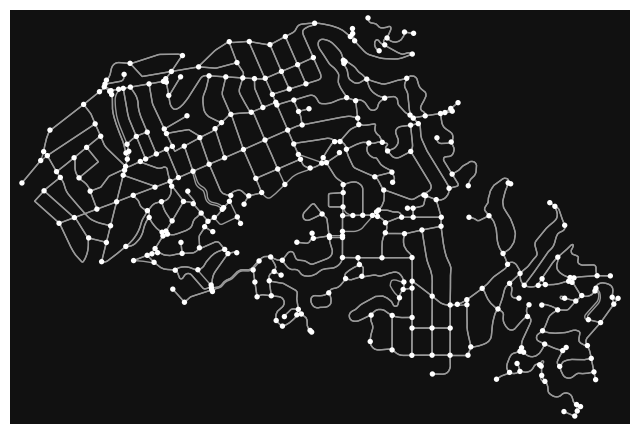

In [2]:
# download/model a street network for some city then visualize it
prep=preprocessing()
# prep.get_graph("Lerm-et-musset, France", network_type="drive", show=True)
prep.get_graph("Piedmont, California, USA", network_type="drive", show=True)

### Preprocessing

In [3]:
prep.add_attributes(show=True)

{'osmid': 6345781, 'highway': 'residential', 'name': 'Rose Avenue', 'oneway': False, 'reversed': False, 'length': np.float64(230.12441194959652), 'geometry': <LINESTRING (-122.248 37.826, -122.248 37.826, -122.246 37.828)>, 'load': 0, 'weight': 1, 'capacity': 10}


In [4]:
# Get strongly connected component
print(prep.get_lscc_size(prop=True))
prep.graph=prep.graph.subgraph(prep.get_lscc())
G=ox.project_graph(prep.graph)

0.9914772727272727


### Bla

In [5]:
class Simulation(Sim):

    def sim_step(self, time_step=20):
        self.info=[]
        if not self.all_completed():
            if self.attack :
                self.attack_helper.launch_attack(self.step)
            if self.repair :
                self.attack_helper.repair_attack(self.step)
            if type(self.calc_helper)==rk_helper:
                self.calc_helper.reset_all_paths()
            all_paths=self.calculate_paths(dist=3)
            self.update_fleet(time_step)
            self.step+=1
            self.clock+=datetime.timedelta(seconds=time_step)
            self.trajs = pd.concat([self.trajs, self.format_trajs_step()]).pipe(gpd.GeoDataFrame)


### Dynamique induite et update

 99%|█████████▉| 99/100 [00:06<00:00, 24.47it/s]

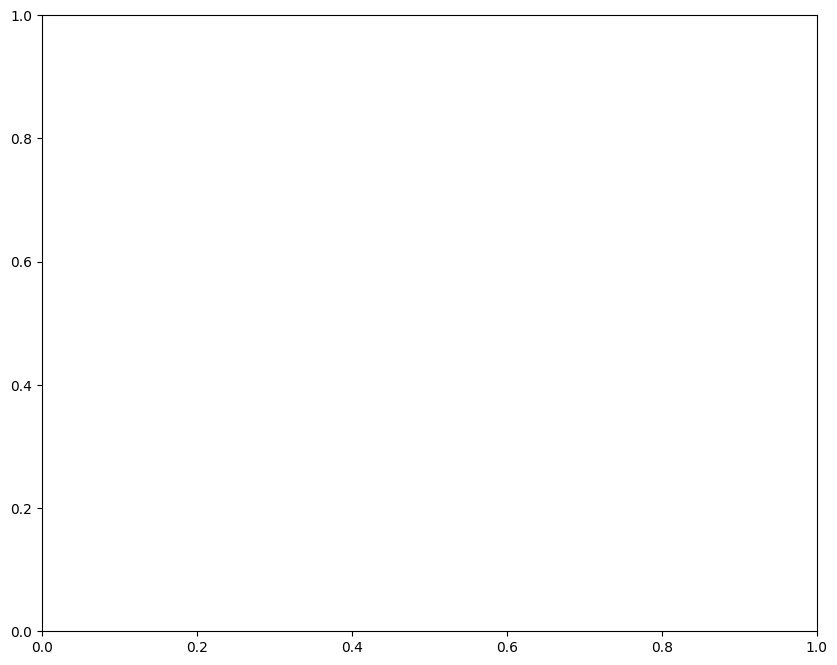

101it [00:13,  7.43it/s]                        


In [ ]:
demand=Simulation(G.copy(), rk_helper, attack=False, repair=False, size=1000, log_trajs=1000)
frames=100
logging.info(f'_'*30)

def update(frame, display=False):
    pbar.update(1)
    if demand.all_completed():
        return ax,
    
    ax.clear()
    if frame > 0:
        demand.sim_step(time_step=5)
    if display:
        # demand.display_h.display_huge(demand, ax=ax)
        demand.display_h.display(demand, ax=ax)
        # demand.display_h.display_graph(demand.calc_helper.nx_graph, demand)
        string=demand.display_h.format_string(demand)
        ax.text(0.05, 0.95, string,
                transform=ax.transAxes, fontsize=12, color='white', 
                bbox=dict(facecolor='black', alpha=0.5))
        return ax,  

with tqdm(total=frames) as pbar:
    fig, ax = plt.subplots(figsize=(10, 8))
    ani = FuncAnimation(fig, update, frames=frames, interval=150, repeat=False)
    ani.save("ani.gif", writer='pillow', 
            #  progress_callback = lambda i, n: print(f'Saving frame {i}/{n}', end='\r')
             )
    plt.show()
UnitTest(demand).run()

### Viz

In [7]:
dis=Display()
m=dis.display_heatmap(demand)

In [8]:
demand.save_trajs('tmp.gpkg')

In [9]:
dis=Display()
m=dis.highlight_node(demand.calc_helper.nx_graph, 245384115, markers=[Point(568399.562347318, 4185934.875910906),Point(568345.8942650286, 4186300.3485423014)])